In [1]:
import numpy as np
import pandas as pd
df= pd.read_csv("titanic.csv")

In [2]:
pd.set_option('display.max_columns', None)  #show withput hiding

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.tail(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [7]:
df.shape

(891, 12)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

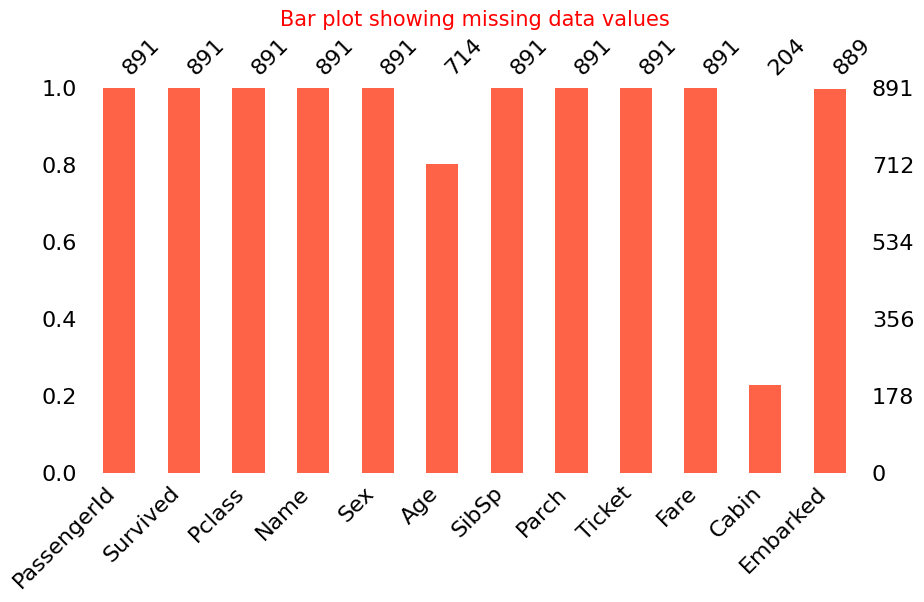

In [10]:
import matplotlib.pyplot as plt
import missingno as ms

ms.bar(df,figsize = (10,5),color="tomato")
plt.title("Bar plot showing missing data values", size = 15,c="r")
plt.show()

In [11]:
df.drop(['Cabin'], axis=1, inplace=True)
df.shape

(891, 11)

In [12]:
df["Embarked"].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [13]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [14]:
df["Embarked"].fillna(df["Embarked"].mode()[0])

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [15]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [16]:
df["Age"].value_counts()

Age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [17]:
print(df["Age"].mean())

print(df["Age"].median())

df["Age"].mode().value_counts()

29.69911764705882
28.0


Age
24.0    1
Name: count, dtype: int64

In [18]:
print(df.describe().astype(int))

       PassengerId  Survived  Pclass  Age  SibSp  Parch  Fare
count          891       891     891  714    891    891   891
mean           446         0       2   29      0      0    32
std            257         0       0   14      1      0    49
min              1         0       1    0      0      0     0
25%            223         0       2   20      0      0     7
50%            446         0       3   28      0      0    14
75%            668         1       3   38      1      0    31
max            891         1       3   80      8      6   512


In [19]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [20]:
print(df["Age"].isnull().sum())

0


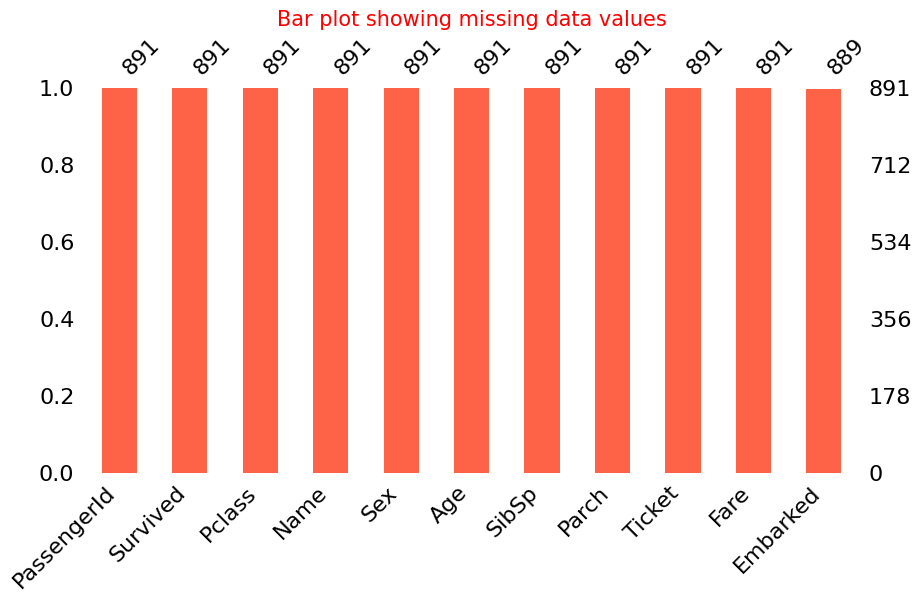

In [21]:
import matplotlib.pyplot as plt
import missingno as ms

ms.bar(df,figsize = (10,5),color="tomato")
plt.title("Bar plot showing missing data values", size = 15,c="r")
plt.show()

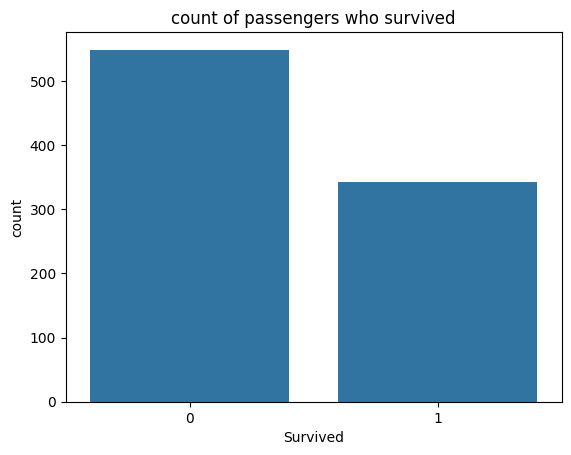

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Survived", data=df)
plt.title("count of passengers who survived")
plt.show()

In [23]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

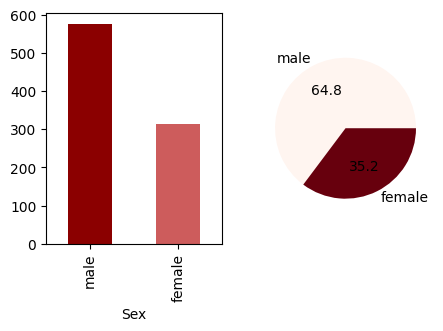

In [24]:
fig,axes = plt.subplots(1,2,figsize=(5,3))
df["Sex"].value_counts().plot(kind="bar", ax=axes[0], color =['DarkRed','indianred'])
df["Sex"].value_counts().plot(kind="pie",ax=axes[1],autopct='%0.1f' ,colormap="Reds")
plt.show()

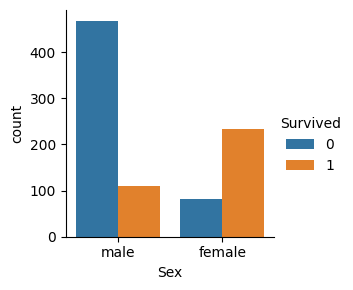

In [25]:
sns.catplot(x="Sex",hue="Survived", kind="count",data=df,height=3,)
plt.show()

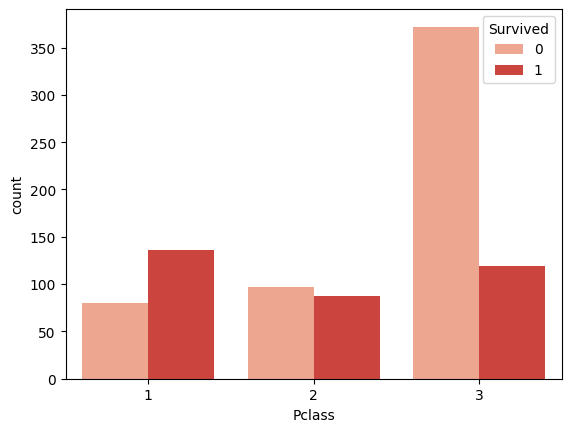

In [26]:
sns.countplot(x="Pclass", hue="Survived", data=df, palette="Reds",)
plt.show()

In [27]:
df.drop(["Name","Ticket","PassengerId"],axis=1,inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [28]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [29]:
df.corr()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Survived,1.000000,-0.338481,-0.543351,-0.064910,-0.035322,0.081629,0.257307,-0.163517
Pclass,-0.338481,1.000000,0.131900,-0.339898,0.083081,0.018443,-0.549500,0.157112
Sex,-0.543351,0.131900,1.000000,0.081163,-0.114631,-0.245489,-0.182333,0.104057
Age,-0.064910,-0.339898,0.081163,1.000000,-0.233296,-0.172482,0.096688,-0.014205
SibSp,-0.035322,0.083081,-0.114631,-0.233296,1.000000,0.414838,0.159651,0.066654
Parch,0.081629,0.018443,-0.245489,-0.172482,0.414838,1.000000,0.216225,0.038322
Fare,0.257307,-0.549500,-0.182333,0.096688,0.159651,0.216225,1.000000,-0.221226
Embarked,-0.163517,0.157112,0.104057,-0.014205,0.066654,0.038322,-0.221226,1.000000


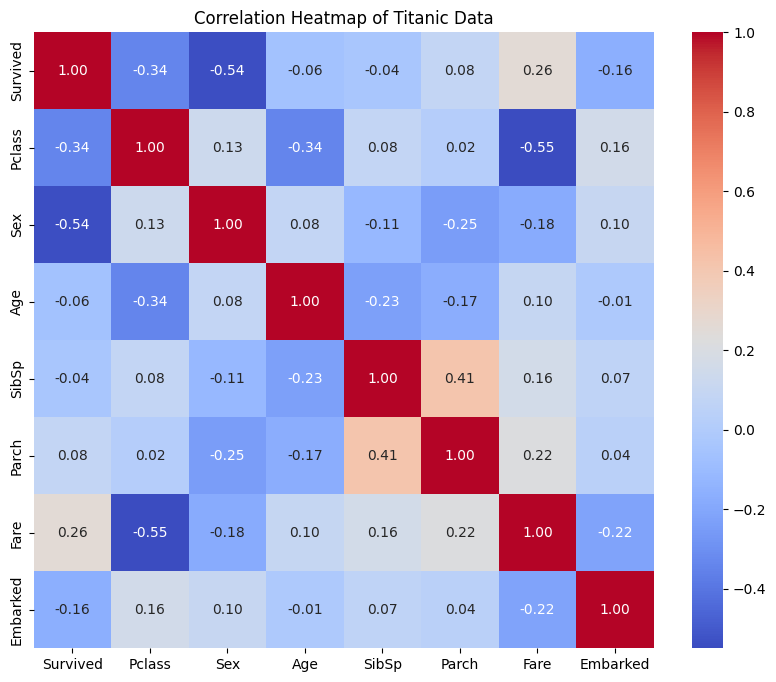

In [30]:
plt.figure(figsize=(10, 8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Titanic Data')
plt.show()

In [31]:
x=df.drop(["Survived"],axis=1)
y=df["Survived"]

In [32]:
print("XXXX",x)
print("YYYY",y)

XXXX      Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         3    1  22.0      1      0   7.2500         2
1         1    0  38.0      1      0  71.2833         0
2         3    0  26.0      0      0   7.9250         2
3         1    0  35.0      1      0  53.1000         2
4         3    1  35.0      0      0   8.0500         2
..      ...  ...   ...    ...    ...      ...       ...
886       2    1  27.0      0      0  13.0000         2
887       1    0  19.0      0      0  30.0000         2
888       3    0  28.0      1      2  23.4500         2
889       1    1  26.0      0      0  30.0000         0
890       3    1  32.0      0      0   7.7500         1

[891 rows x 7 columns]
YYYY 0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


In [33]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=12)   #split the val

In [34]:
print("DF",df.shape)
print("x_train",x_train.shape)
print("x_test",x_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)

DF (891, 8)
x_train (712, 7)
x_test (179, 7)
y_train (712,)
y_test (179,)


In [35]:
from sklearn.naive_bayes import GaussianNB  
NB = GaussianNB()

NB.fit(x_train, y_train)

###train the data
y_pred=NB.predict(x_test)
print("y_pred",y_pred)


y_pred [0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 1 0 0 1 0
 0 0 1 0 0 1 1 0 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 1 1 1 0 1 1 1 0 0 0 0 0 1
 1 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 1 1 0 0 0 1 0 0 0 0 0 1 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 1 0 1 1 1 0 1 0 1 1 0 1 1 0 0 1 1 0 1
 1 1 0 1 0 1 0 0 0 1 1 0 0 0 0 0 1 0 1 1 1 0 0 1 0 1 0 0 0 0 1]


In [36]:
print("y_test",y_test)

y_test 456    0
351    0
173    0
671    0
836    0
      ..
877    0
35     0
814    0
363    0
871    1
Name: Survived, Length: 179, dtype: int64


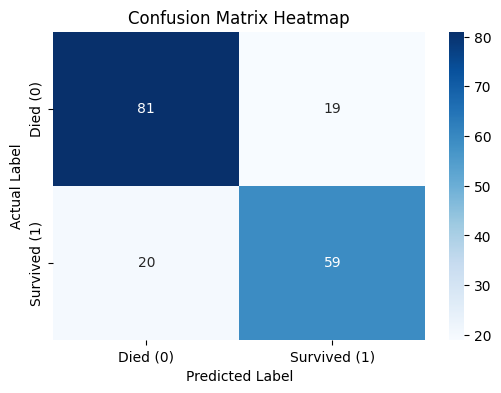

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Died (0)', 'Survived (1)'], 
            yticklabels=['Died (0)', 'Survived (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [38]:
acc = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {acc * 100:.2f}%")


Overall Accuracy: 78.21%
